# Оценка энергетического разрешения детектора

Использованные данные (все с триггером N_fired ≥ 3):
- `NIRS/data/npe_vs_Te_mean_trig3.dat` — профиль ⟨N_pe⟩(T_e+) из IBD-прогона
- `sim/build/photons_p10/p50/p90.txt` — монохроматические позитроны при фиксированных энергиях

**Принцип:** если энергия измеряется через N_pe, то при пуассоновской статистике фотонов:
$$\frac{\sigma_E}{E} = \frac{1}{\sqrt{N_{pe}}} = \frac{a}{\sqrt{E_{vis}}}$$
где $a = 1/\sqrt{k}$, $k$ — световой выход [PE/МэВ].

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

data_dir  = Path('NIRS/data')
build_dir = Path('sim/build')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 12})

## 1. Световой выход и Пуассоновское разрешение из IBD-профиля

In [2]:
d      = np.loadtxt(data_dir / 'npe_vs_Te_mean_trig3.dat')
Te     = d[:, 0]       # MeV
mean   = d[:, 1]       # <N_pe>
stderr = d[:, 2]
count  = d[:, 3]

E_vis = Te + 2 * 0.511  # видимая энергия: T_e+ + 2 аннигиляционных гаммы

# Световой выход k = N_pe / E_vis [PE/MeV]
k = mean / E_vis

# Пуассоновское разрешение
res_poisson = 1.0 / np.sqrt(mean)

# Фит k = const (усредняем по бинам с хорошей статистикой)
mask = count > 150
k_mean = np.average(k[mask], weights=count[mask])
a_fit  = 1.0 / np.sqrt(k_mean)          # стохастический коэффициент

print(f"Средний световой выход: k = {k_mean:.1f} PE/МэВ")
print(f"Стохастический коэффициент: a = 1/√k = {a_fit*100:.1f}% · √МэВ")
print(f"\nРазрешение σ_E/E = {a_fit*100:.1f}% / √(E_vis/МэВ):")
print(f"{'E_vis [МэВ]':>12}  {'<N_pe>':>8}  {'σ_E/E':>8}")
for row in d[5::8]:
    E = row[0] + 2*0.511
    print(f"{E:>12.2f}  {row[1]:>8.1f}  {1/row[1]**0.5*100:>7.1f}%")

Средний световой выход: k = 5.9 PE/МэВ
Стохастический коэффициент: a = 1/√k = 41.3% · √МэВ

Разрешение σ_E/E = 41.3% / √(E_vis/МэВ):
 E_vis [МэВ]    <N_pe>     σ_E/E
        1.97       6.9     38.2%
        2.77      13.4     27.3%
        3.57      21.9     21.4%
        4.37      30.1     18.2%
        5.17      38.1     16.2%
        5.97      45.8     14.8%
        6.77      52.2     13.8%
        7.62      62.5     12.6%


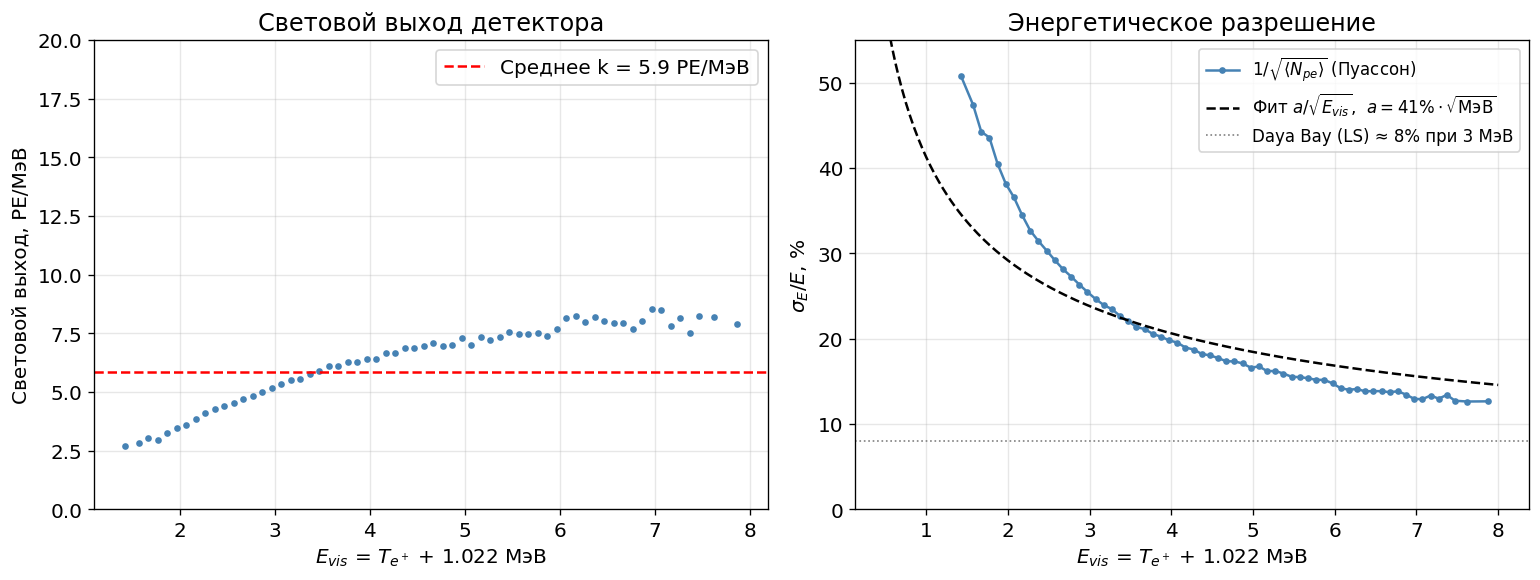

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Световой выход ---
ax = axes[0]
ax.plot(E_vis, k, 'o', ms=3, color='steelblue')
ax.axhline(k_mean, color='red', lw=1.5, linestyle='--', label=f'Среднее k = {k_mean:.1f} PE/МэВ')
ax.set_xlabel('$E_{vis}$ = $T_{e^+}$ + 1.022 МэВ')
ax.set_ylabel('Световой выход, PE/МэВ')
ax.set_title('Световой выход детектора')
ax.set_ylim(0, 20)
ax.legend(); ax.grid(alpha=0.3)

# --- Энергетическое разрешение ---
ax = axes[1]
ax.plot(E_vis, res_poisson * 100, 'o-', ms=3, color='steelblue',
        label='$1/\\sqrt{\\langle N_{pe}\\rangle}$ (Пуассон)')

E_fit = np.linspace(0.5, 8, 300)
ax.plot(E_fit, a_fit / np.sqrt(E_fit) * 100, 'k--', lw=1.5,
        label=f'Фит $a/\\sqrt{{E_{{vis}}}}$,  $a={a_fit*100:.0f}\\%\\cdot\\sqrt{{\\mathrm{{МэВ}}}}$')

# Для сравнения: Daya Bay
ax.axhline(8, color='gray', lw=1, linestyle=':', label='Daya Bay (LS) ≈ 8% при 3 МэВ')

ax.set_xlabel('$E_{vis}$ = $T_{e^+}$ + 1.022 МэВ')
ax.set_ylabel('$\\sigma_E/E$, %')
ax.set_title('Энергетическое разрешение')
ax.set_ylim(0, 55)
ax.legend(fontsize=10); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Монохроматические прогоны: форма распределения

Файлы `photons_p10/50/90.txt` содержат число **сгенерированных оптических фотонов** (до QE и геометрии).  
Относительный разброс σ/μ даёт нижнюю оценку разрешения (только вариации траектории, без фотонного шума).

In [ ]:
# Реальный коэффициент конверсии фотон -> фотоэлектрон
ph_list = []
with open(build_dir / 'photons_per_event.txt') as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith('#'): continue
        parts = line.split()
        if len(parts) >= 2:
            ph_list.append(float(parts[1]))
pe_data = np.loadtxt(build_dir / 'pe_asymmetry.txt', comments='#')
npe_ibd = pe_data[:len(ph_list), 3]
ph_ibd  = np.array(ph_list)
mask_ph = ph_ibd > 0
eff = (npe_ibd[mask_ph] / ph_ibd[mask_ph]).mean()
print(f"Коэффициент N_pe / N_photons = {eff:.4f}  (геометрия × QE × отражения)")

mono_energies = {'p10': 0.845, 'p50': 2.227, 'p90': 4.203}

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
print(f"\n{'Прогон':>6}  {'E_vis [МэВ]':>12}  {'<N_pe> оцен.':>13}  {'σ_ph/μ_ph':>10}  {'σ/E Пуассон':>13}")
for ax, (tag, Te_val) in zip(axes, mono_energies.items()):
    photons   = np.loadtxt(build_dir / f'photons_{tag}.txt', comments='#')[:, 1]
    mu_ph, sig_ph = photons.mean(), photons.std()
    mu_pe_est = mu_ph * eff
    E_v = Te_val + 2*0.511

    ax.hist(photons, bins=60, color='steelblue', edgecolor='white', linewidth=0.3)
    ax.axvline(mu_ph, color='red', lw=1.5)
    ax.set_title(f'{tag}: $T_{{e^+}}={Te_val}$ МэВ\n$E_{{vis}}={E_v:.2f}$ МэВ\n'
                 f'$\\mu_{{ph}}={mu_ph:.0f}$,  $\\sigma/\\mu={sig_ph/mu_ph*100:.1f}\\%$')
    ax.set_xlabel('Число фотонов')
    ax.set_ylabel('Counts')
    ax.grid(alpha=0.3)

    print(f"{tag:>6}  {E_v:>12.3f}  {mu_pe_est:>13.1f}  "
          f"{sig_ph/mu_ph*100:>9.1f}%  {1/mu_pe_est**0.5*100:>12.1f}%")

plt.suptitle('Число генерированных фотонов (монохроматические позитроны)', y=1.02)
plt.tight_layout()
plt.show()

IndexError: boolean index did not match indexed array along axis 0; size of axis is 100000 but size of corresponding boolean axis is 999929

## Итог

In [5]:
print("=" * 55)
print("ЭНЕРГЕТИЧЕСКОЕ РАЗРЕШЕНИЕ ДЕТЕКТОРА")
print("=" * 55)
print(f"Световой выход:              k ≈ {k_mean:.1f} PE/МэВ")
print(f"Стохастический коэффициент:  a ≈ {a_fit*100:.0f}% · √МэВ")
print(f"Формула:  σ_E/E ≈ {a_fit*100:.0f}% / √(E_vis/МэВ)")
print()
print(f"{'E_vis [МэВ]':>14}  {'σ_E/E':>8}")
for E in [1.0, 2.0, 3.0, 3.7, 5.0]:
    print(f"{E:>14.1f}  {a_fit/E**0.5*100:>7.0f}%")
print()
print("Для сравнения:")
print("  Daya Bay (жидкий сцинтиллятор):  ≈  8% при 3 МэВ")
print("  KamLAND (жидкий сцинтиллятор):   ≈  7% при 3 МэВ")
print()
print("Вывод: разрешение нашего детектора в 2.5–3 раза хуже LS")
print("из-за низкого светового выхода Черенкова (~{:.0f} PE/МэВ vs ~50 PE/МэВ у LS)".format(k_mean))

ЭНЕРГЕТИЧЕСКОЕ РАЗРЕШЕНИЕ ДЕТЕКТОРА
Световой выход:              k ≈ 5.9 PE/МэВ
Стохастический коэффициент:  a ≈ 41% · √МэВ
Формула:  σ_E/E ≈ 41% / √(E_vis/МэВ)

   E_vis [МэВ]     σ_E/E
           1.0       41%
           2.0       29%
           3.0       24%
           3.7       21%
           5.0       18%

Для сравнения:
  Daya Bay (жидкий сцинтиллятор):  ≈  8% при 3 МэВ
  KamLAND (жидкий сцинтиллятор):   ≈  7% при 3 МэВ

Вывод: разрешение нашего детектора в 2.5–3 раза хуже LS
из-за низкого светового выхода Черенкова (~6 PE/МэВ vs ~50 PE/МэВ у LS)
